In [4]:
import sys
import os

# # Add the current file’s directory (or parent) to sys.path
# sys.path.append(os.path.dirname(os.path.abspath(__file__)))
# OR, if you’re in a Jupyter notebook:
# Go up two levels from the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# Add that directory to Python's import path
sys.path.append(parent_dir)

In [20]:
import yaml
import torch
import sys, os

# Go to project root (two parents up from tests/)
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(project_root)

# Import
from src.blocks.SpectogramBlock import SpectrogramBlock


# Load YAML
with open("../../configs/spectogram.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Extract parameters
params = cfg["model"]["blocks"][0]["params"]

# Build the block
model = SpectrogramBlock(**params)

# Run a test
x = torch.randn(1, 1, 240000)
spec_dict = model(x)

print(spec_dict.keys())  # Should show the keys in the output dictionary


dict_keys(['freq_spec', 'time_spec', 'recon_spec', 'recon_wave'])


In [21]:
for key, value in spec_dict.items():
    print(f"{key}: {value.shape}")

freq_spec: torch.Size([1, 1, 2001, 201])
time_spec: torch.Size([1, 1, 501, 801])
recon_spec: torch.Size([1, 1, 1001, 401])
recon_wave: torch.Size([1, 1, 240000])


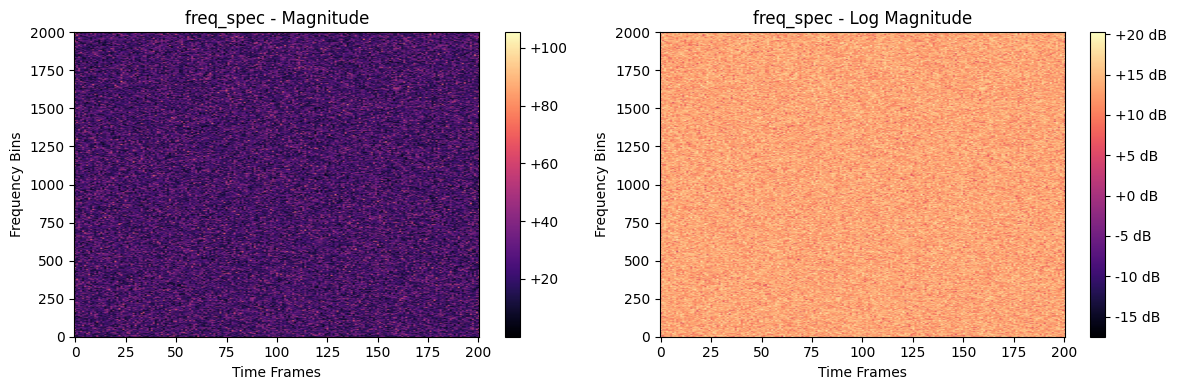

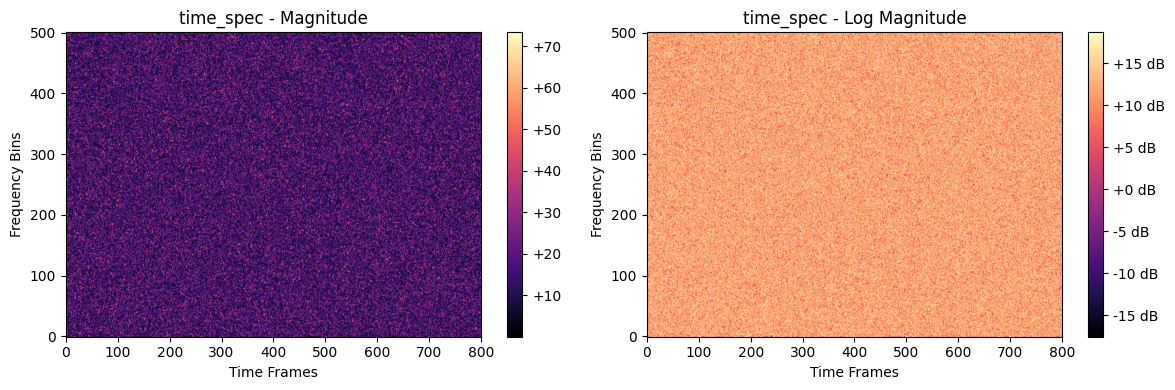

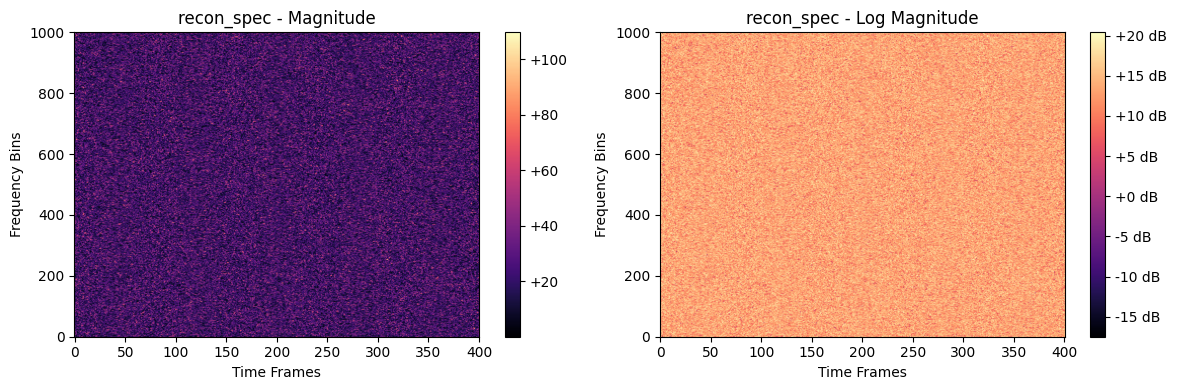

In [24]:
import matplotlib.pyplot as plt
import torch

def visualize_spectrogram_pair(spectrogram, title="Spectrogram"):
    """
    Plots two images per spectrogram:
      - Left: Magnitude
      - Right: Log-magnitude (dB)
    """
    # Ensure tensor is real-valued or convert magnitude
    if torch.is_complex(spectrogram):
        mag = spectrogram.abs()
    else:
        mag = spectrogram

    log_mag = 10 * torch.log10(mag + 1e-10)

    # Plot side by side
    plt.figure(figsize=(12, 4))

    # Magnitude
    plt.subplot(1, 2, 1)
    plt.imshow(mag.squeeze().cpu().numpy(), origin='lower', aspect='auto', cmap='magma')
    plt.colorbar(format='%+2.0f')
    plt.title(f"{title} - Magnitude")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")

    # Log-magnitude
    plt.subplot(1, 2, 2)
    plt.imshow(log_mag.squeeze().cpu().numpy(), origin='lower', aspect='auto', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{title} - Log Magnitude")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")

    plt.tight_layout()
    plt.show()

# Example: plot first 3 spectrograms from dictionary
for i, (key, value) in enumerate(spec_dict.items()):
    if i == 3:
        break
    visualize_spectrogram_pair(value, title=key)


TypeError: Image data of dtype complex64 cannot be converted to float

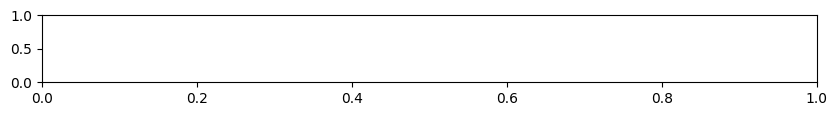

In [19]:
spec_dict['freq_spec']

tensor([[[[-24.5217+0.0000e+00j,  14.3109+0.0000e+00j, -15.5783+0.0000e+00j,
            ..., -17.6791+0.0000e+00j,  45.8989+0.0000e+00j,
            23.7479+0.0000e+00j],
          [ 20.8903+3.5482e-07j, -11.7842+1.3428e+01j,  15.0438+6.9681e-01j,
            ...,  23.5085-1.5127e+01j, -40.5094-7.4643e-01j,
           -21.5553-4.2541e-04j],
          [-11.3885+3.5679e-06j,   4.0093-2.1136e+01j, -11.4975-5.6273e+00j,
            ..., -35.0060+2.4289e+01j,  26.3920-6.6611e-02j,
            17.5392+3.5595e-02j],
          ...,
          [-33.5071-8.4202e-07j,   5.9885-2.3411e+01j,  34.6234-3.9049e+00j,
            ..., -32.1642-9.8920e+00j, -27.8070-9.8721e+00j,
           -18.0926+5.1414e-02j],
          [ 19.4137+3.1287e-06j,  -7.1232+1.5810e+01j, -27.0966+1.5173e+00j,
            ...,  40.9851+4.0509e+00j,  27.2775+4.6582e+00j,
            19.2688-2.7765e-02j],
          [-13.3396+0.0000e+00j,   7.5553+0.0000e+00j,  23.4588+0.0000e+00j,
            ..., -44.4417+0.0000e+00j, -27.1512+